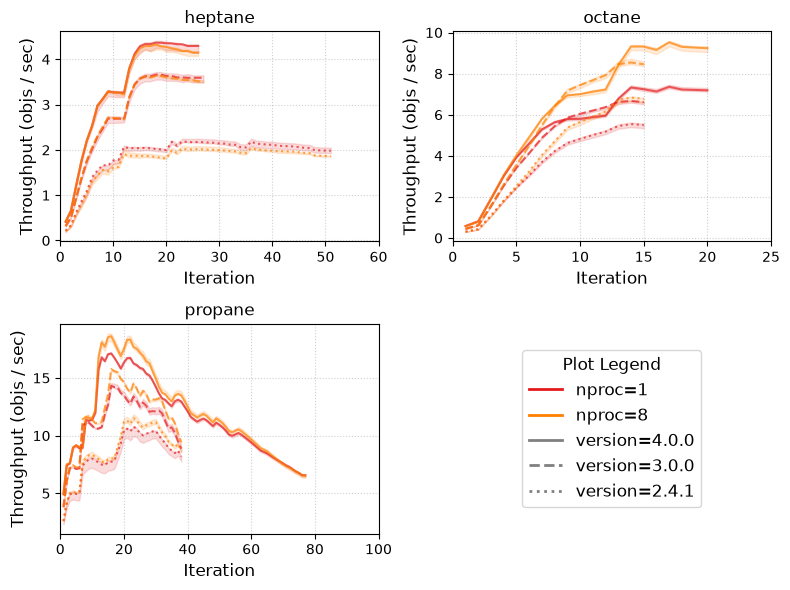

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load data
candidates = sorted(Path(".").glob("rmgpy_output_*"))
src = candidates[-1] / "benchmark_summary.csv" if candidates else Path("benchmark_summary.csv")
df = pd.read_csv(src)

df = df[~df['nproc'].isin((2, 4))]
df = df[df['benchmark'] != 'diesel']

# Parsing time
def parse_time(time_str):
    parts = str(time_str).split(':')
    if len(parts) == 4:
        d, h, m, s = map(int, parts)
        return d * 86400 + h * 3600 + m * 60 + s
    elif len(parts) == 3:
        h, m, s = map(int, parts)
        return h * 3600 + m * 60 + s
    return 0

df['total_seconds'] = df['exec_time_dd_hh_mm_ss'].apply(parse_time)
df['total_objects'] = df['core_species'] + df['core_reactions'] + df['edge_species'] + df['edge_reactions']
# Replace 0 with 1 to avoid division by zero (though total_seconds is unlikely 0)
df['throughput'] = df['total_objects'] / df['total_seconds'].replace(0, 1)

# Sorting values
df = df.sort_values(by=['benchmark', 'version', 'nproc', 'run', 'iteration'])

benchmarks = sorted(df['benchmark'].unique())
nprocs = sorted(df['nproc'].unique())
versions = ("4.0.0", "3.0.0", "2.4.1")

# Setup colors and styles
nproc_colors = {np: plt.cm.Set1(i/len(nprocs)) for i, np in enumerate(nprocs)}
version_styles = {v: style for v, style in zip(versions, ['-', '--', ':'])}

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

# Legend elements
legend_elements = []
for np in nprocs:
    legend_elements.append(Line2D([0], [0], color=nproc_colors[np], lw=2, label=f"nproc={np}"))
for v in versions:
    legend_elements.append(Line2D([0], [0], color='gray', linestyle=version_styles[v], lw=2, label=f"version={v}"))

for i, bench in enumerate(benchmarks):
    ax = axes[i]
    bench_df = df[df['benchmark'] == bench]
    
    for v in versions:
        for np in nprocs:
            subset = bench_df[(bench_df['version'] == v) & (bench_df['nproc'] == np)]
            if not subset.empty:
                # Calculate median, min, and max across repetitions
                grouped = subset.groupby('iteration')['throughput'].agg(
                    med='median', ymin='min', ymax='max'
                ).reset_index()
                
                # Plot median line
                ax.plot(grouped['iteration'], grouped['med'], 
                         color=nproc_colors[np], 
                         linestyle=version_styles[v],
                         markersize=0, alpha=0.7)
                
                # Fill min-max shading
                ax.fill_between(grouped['iteration'], grouped['ymin'], grouped['ymax'],
                                color=nproc_colors[np], alpha=0.15)
    
    ax.set_title(bench, fontsize=12)
    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel("Throughput (objs / sec)", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xticks([round(tick) for tick in ax.get_xticks()])
    ax.set_xlim(0)

# Legend tile
ax_legend = axes[3]
ax_legend.axis('off')
ax_legend.legend(handles=legend_elements, loc='center', title="Plot Legend", fontsize=12, title_fontsize=12, ncol=1)

plt.tight_layout()
plt.savefig(src.parent.resolve() / 'throughput_benchmark_plot.pdf')
plt.show()

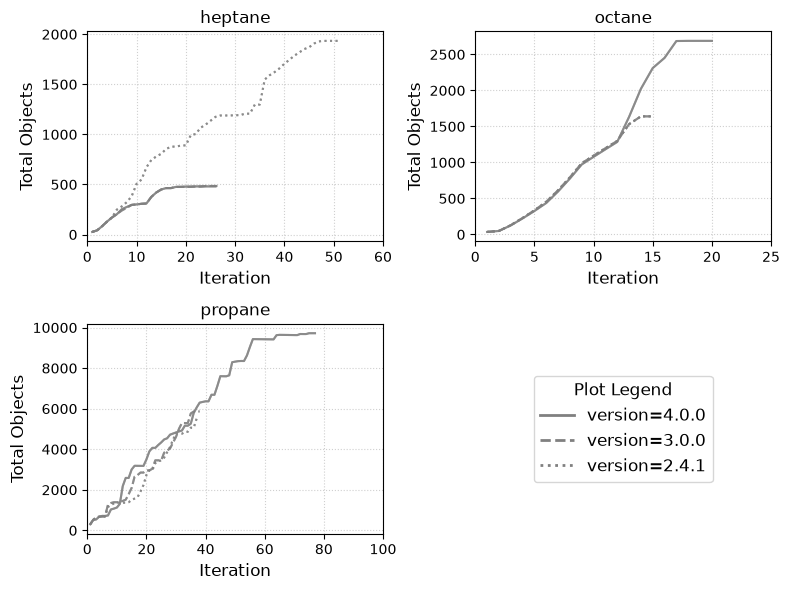

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

# Place for lines to gather handles
# We will create manual legend entries to avoid repeats
legend_elements = []
for v in versions:
    legend_elements.append(Line2D([0], [0], color='gray', linestyle=version_styles[v], lw=2, label=f"version={v}"))

for i, bench in enumerate(benchmarks):
    ax = axes[i]
    bench_df = df[df['benchmark'] == bench]
    
    for v in versions:
        for np in nprocs:
            subset = bench_df[(bench_df['version'] == v) & (bench_df['nproc'] == 1)]
            if not subset.empty:
                # Calculate median across the repetitions
                median_data = subset.groupby('iteration', as_index=False)['total_objects'].median()
                
                ax.plot(median_data['iteration'], median_data['total_objects'], 
                         color='gray', 
                         linestyle=version_styles[v],
                         marker='o', markersize=0, alpha=0.7)
    
    ax.set_title(bench, fontsize=12)
    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel("Total Objects", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    # round x ticks
    ax.set_xticks([round(i) for i in ax.get_xticks()])
    ax.set_xlim(0)

# Legend tile
ax_legend = axes[3]
ax_legend.axis('off')
ax_legend.legend(handles=legend_elements, loc='center', title="Plot Legend", fontsize=12, title_fontsize=12, ncol=1)

plt.tight_layout()
plt.savefig(src.parent.resolve() / 'core_species_vs_iteration.pdf')
plt.show()

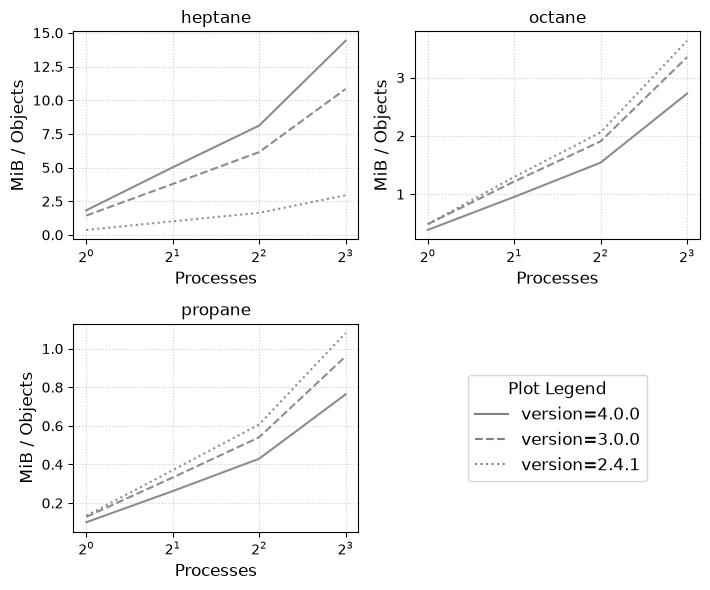

In [3]:
mem_src = src.parent / "results.csv"
mem_df = pd.read_csv(mem_src)
mem_df = mem_df.query("case != 'diesel'").copy()

size_lookup = df[["version", "benchmark", "total_objects"]].groupby(["version", "benchmark"]).max().to_dict(orient='dict')['total_objects']
mem_df["total_size"] = mem_df.apply(lambda row: size_lookup.get((row['version'], row['case']), 1), axis=1)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

legend_elements = [
    Line2D([0], [0], color='gray', linestyle=version_styles[v], label=f"version={v}")
    for v in versions
]

for i, bench in enumerate(benchmarks):
    ax = axes[i]
    bench_df = mem_df[mem_df['case'] == bench]

    for v in versions:
        subset = bench_df[bench_df['version'] == v].copy()

        if not subset.empty:
            subset['normalized_mem'] = subset['peak_rss_mib'] / subset['total_size']
            
            # Calculate median across the repetitions and sort by processes
            median_data = subset.groupby('processes', as_index=False)['normalized_mem'].median().sort_values('processes')
            
            ax.plot(
                median_data['processes'],
                median_data['normalized_mem'],
                color='gray',
                markersize=0,
                linestyle=version_styles[v],
                alpha=0.9
            )

    ax.set_title(bench, fontsize=12)
    ax.set_xlabel("Processes", fontsize=12)
    ax.set_ylabel("MiB / Objects", fontsize=12)
    ax.set_xticks(nprocs)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xscale('log', base=2)

ax_legend = axes[3]
ax_legend.axis('off')
ax_legend.legend(handles=legend_elements, loc='center', title="Plot Legend", fontsize=12, title_fontsize=12, ncol=1)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig(mem_src.parent.resolve() / "memory_vs_processes.pdf", dpi=300)
plt.show()